
## FINAL — PHASE : Dynamic Ensemble (Model Ensemble)

Since we obtain in the best trainings almost 80%, the standard standard technique is to combine the predictions of the two best-performing architectures:

- **ConvNeXt-Small:** Captures global patterns and complex contextual relationships, thanks to its `7 × 7` kernels.
- **EfficientNet-V2-S:** Captures fine-grained edge details and low-scale textures, thanks to its deep convolutions with smaller kernels.

Final evaluation and matrix plot

In [ ]:
import os, glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image, ImageFile

Image.MAX_IMAGE_PIXELS = None
ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Dispositivo activo: {device}")

IMG_SIZE = 384
BATCH_SIZE = 16


# best wheights (.pth)

def find_weight_file(filename):
    if os.path.exists(filename):
        return filename
    matches = glob.glob(f"/kaggle/**/{filename}", recursive=True)
    if matches:
        return matches[0]
    return None

convnext_path = find_weight_file("/kaggle/input/notebooks/mariajgamboa/prueba04-newarch/convnext_small_384_clamm.pth")
effnet_path = find_weight_file("/kaggle/input/notebooks/mariajgamboa/2-1-1bestnotebook/efficientnet_v2_silu_384_clamm.pth")

print(f" Ruta ConvNeXt: {convnext_path}")
print(f" Ruta EfficientNet: {effnet_path}")


# Metadata y Validacion

DATA_DIR = "/kaggle/input/datasets/mariajgamboa/clammdst/CLaMM_DST"
CSV_PATH = os.path.join(DATA_DIR, "CLaMM_Metadata.csv")
df = pd.read_csv(CSV_PATH, sep=None, engine='python')
df.columns = df.columns.str.strip()
script_col = [col for col in df.columns if col.upper() == 'SCRIPT_TYPE'][0]
df['label'] = df[script_col].astype(int) - 1
num_classes = df['label'].nunique()

all_image_paths = (
    glob.glob(f"{DATA_DIR}/**/*.[jJ][pP][gG]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[pP][nN][gG]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[tT][iI][fF]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[jJ][pP][eE][gG]", recursive=True))
image_map = {os.path.basename(p).lower(): p for p in all_image_paths}

class CLaMMDataset(Dataset):
    def __init__(self, df, image_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['FILENAME']).strip().lower()

        if img_name in self.image_map:
            final_path = self.image_map[img_name]
        else:
            base_name = os.path.splitext(img_name)[0]
            matched = None
            for ext in ['.jpg', '.jpeg', '.tif', '.png']:
                if (base_name + ext) in self.image_map:
                    matched = self.image_map[base_name + ext]
                    break
            final_path = matched

        image = Image.open(final_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(row['label'], dtype=torch.long)

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = CLaMMDataset(df=df, image_map=image_map, transform=val_tf)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

_, val_dataset_split = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(42))

val_loader = DataLoader(val_dataset_split, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


#  Modelo 1: ConvNeXt-Small

print("\n Cargando ConvNeXt-Small...")
model_convnext = models.convnext_small(weights=None)
in_features_c = model_convnext.classifier[2].in_features
model_convnext.classifier[2] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features_c, num_classes)
)
model_convnext.load_state_dict(torch.load(convnext_path, map_location=device))
model_convnext = model_convnext.to(device)
model_convnext.eval()


# Modelo 2: EfficientNet-V2-S 

print(" Cargando EfficientNet-V2-S...")
model_effnet = models.efficientnet_v2_s(weights=None)
in_features_e = model_effnet.classifier[1].in_features

# Estructura idéntica a los pesos guardados en el archivo .pth
model_effnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features_e, num_classes)
    )
)

model_effnet.load_state_dict(torch.load(effnet_path, map_location=device))
model_effnet = model_effnet.to(device)
model_effnet.eval()
print(" Pesos de EfficientNet cargados exitosamente (100% de coincidencia).")


# Evaluacion del Ensamble Ponderado
print("\n Evaluando Ensamble en el conjunto de Validación...")

correct_convnext = 0
correct_effnet = 0
correct_ensemble = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        out_c = torch.softmax(model_convnext(images), dim=1)
        out_e = torch.softmax(model_effnet(images), dim=1)

        # Ensamble Ponderado (60% ConvNeXt + 40% EfficientNet)
        out_ensemble = (0.60 * out_c) + (0.40 * out_e)

        _, pred_c = torch.max(out_c, 1)
        _, pred_e = torch.max(out_e, 1)
        _, pred_ens = torch.max(out_ensemble, 1)

        total += labels.size(0)
        correct_convnext += torch.sum(pred_c == labels).item()
        correct_effnet += torch.sum(pred_e == labels).item()
        correct_ensemble += torch.sum(pred_ens == labels).item()

acc_c = (correct_convnext / total) * 100
acc_e = (correct_effnet / total) * 100
acc_ens = (correct_ensemble / total) * 100

print(f"\n Resumen de Resultados Finales:")
print(f" ├─ Accuracy ConvNeXt-Small solo: {acc_c:.2f}%")
print(f" ├─ Accuracy EfficientNet-V2-S solo: {acc_e:.2f}%")
print(f" └─  ACCURACY ENSAMBLE COMBINADO: {acc_ens:.2f}%")

 Dispositivo activo: cuda
 Ruta ConvNeXt: /kaggle/input/notebooks/mariajgamboa/prueba04-newarch/convnext_small_384_clamm.pth
 Ruta EfficientNet: /kaggle/input/notebooks/mariajgamboa/2-1-1bestnotebook/efficientnet_v2_silu_384_clamm.pth

 Cargando ConvNeXt-Small...
 Cargando EfficientNet-V2-S...
 Pesos de EfficientNet cargados exitosamente (100% de coincidencia).

 Evaluando Ensamble en el conjunto de Validación...

 Resumen de Resultados Finales:
 ├─ Accuracy ConvNeXt-Small solo: 79.74%
 ├─ Accuracy EfficientNet-V2-S solo: 78.19%
 └─  ACCURACY ENSAMBLE COMBINADO: 80.40%


              precision    recall  f1-score   support

           0       0.90      0.93      0.91       120
           1       0.78      0.75      0.76       110
           2       0.97      0.88      0.92        41
           3       0.85      0.96      0.90        53
           4       0.93      0.93      0.93        44
           5       0.70      0.68      0.69        79
           6       0.86      0.86      0.86       107
           7       0.66      0.56      0.61        59
           8       0.63      0.57      0.60        70
           9       0.78      0.78      0.78        40
          10       0.75      0.82      0.78       147
          11       1.00      0.97      0.99        38

    accuracy                           0.80       908
   macro avg       0.82      0.81      0.81       908
weighted avg       0.80      0.80      0.80       908



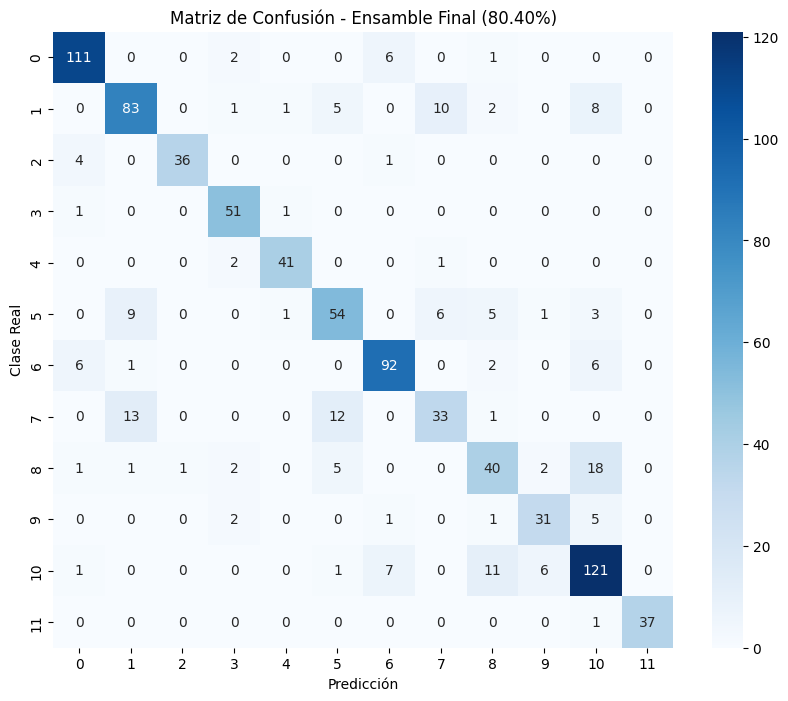

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        out_c = torch.softmax(model_convnext(images), dim=1)
        out_e = torch.softmax(model_effnet(images), dim=1)
        out_ensemble = (0.60 * out_c) + (0.40 * out_e)
        
        _, preds = torch.max(out_ensemble, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Reporte por clase
print(classification_report(all_labels, all_preds))

# Matriz Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión - Ensamble Final (80.40%)')
plt.show()